In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('X.csv')
df.head()

,sw,sg,sw_inj,sg_inj,oil_bank
0,0.08,0.88,0.0,1.0,False
1,0.08,0.88,0.1,0.9,False
2,0.08,0.88,0.2,0.8,False
3,0.08,0.88,0.3,0.7,False
4,0.08,0.88,0.4,0.6,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sw        2208 non-null   float64
 1   sg        2208 non-null   float64
 2   sw_inj    2208 non-null   float64
 3   sg_inj    2208 non-null   float64
 4   oil_bank  2208 non-null   bool   
dtypes: bool(1), float64(4)
memory usage: 71.3 KB


In [4]:
import numpy as np

print("Oil bank - ", np.sum(df['oil_bank'] == 1))
print("no Oil bank - ", np.sum(df['oil_bank'] == 0))

Oil bank -  66
no Oil bank -  2142


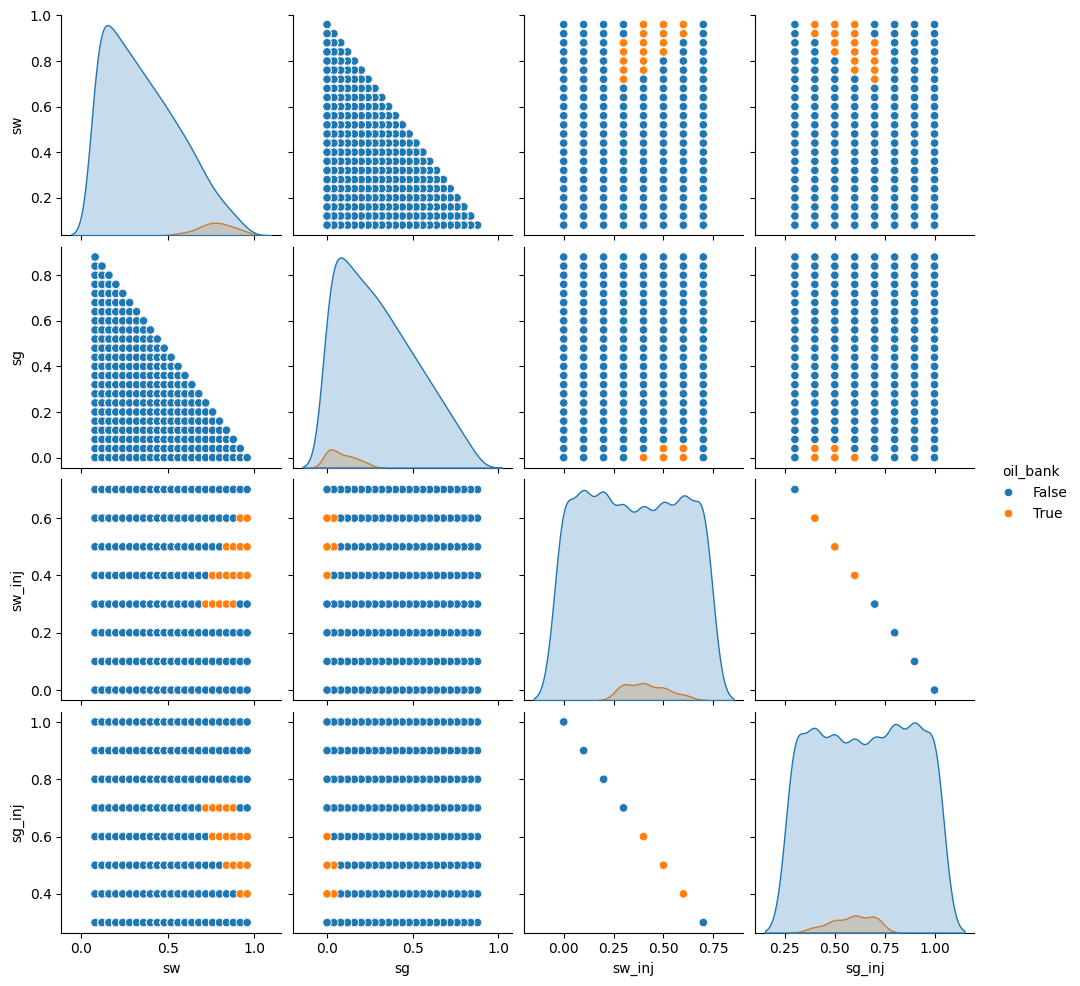

In [5]:
sns.pairplot(df, hue='oil_bank')

In [6]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix


In [7]:
X = df.drop('oil_bank', axis=1)
y = df['oil_bank']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
model = Pipeline([
    ('svc', SVC(kernel='rbf', class_weight='balanced'))
])

In [9]:
model.fit(X_train, y_train)

Pipeline(steps=[('svc', SVC(class_weight='balanced'))])

In [10]:
y_pred = model.predict(X_train)
print(y_pred.shape)

(1766,)


In [11]:
print(y_train.shape)

(1766,)


In [12]:
print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

              precision    recall  f1-score   support

       False       1.00      0.94      0.97      1708
        True       0.36      1.00      0.53        58

    accuracy                           0.94      1766
   macro avg       0.68      0.97      0.75      1766
weighted avg       0.98      0.94      0.95      1766

[[1606  102]
 [   0   58]]


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [0.1, 1, 10, 100, 1000, 10000],
    'svc__gamma': [100, 10, 1, 0.1, 0.01, 0.001],
    'svc__kernel': ['rbf'],
    'svc__class_weight': [None, 'balanced']
}

grid = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best parameters: {'svc__C': 1000, 'svc__class_weight': None, 'svc__gamma': 10, 'svc__kernel': 'rbf'}


In [14]:

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       434
        True       1.00      0.88      0.93         8

    accuracy                           1.00       442
   macro avg       1.00      0.94      0.97       442
weighted avg       1.00      1.00      1.00       442

[[434   0]
 [  1   7]]


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [16]:
# Get continuous scores
y_scores = best_model.decision_function(X_test)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Compute AUC
auc_score = roc_auc_score(y_test, y_scores)

print("ROC AUC:", auc_score)

ROC AUC: 0.9997119815668203


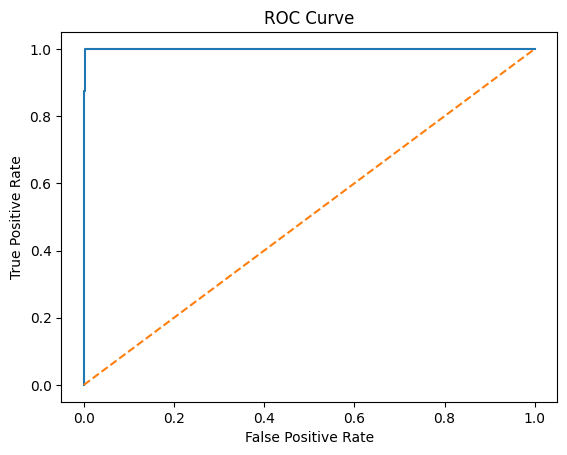

In [17]:
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

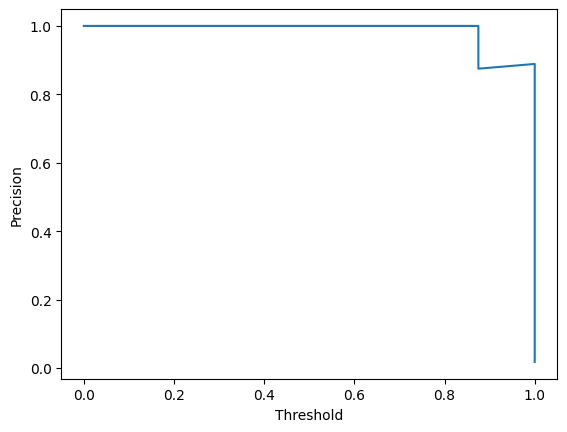

In [18]:
from sklearn.metrics import precision_recall_curve

y_scores = best_model.decision_function(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.show()

In [19]:
threshold = 0.8
y_scores = best_model.decision_function(X_test)
y_pred = (y_scores > threshold).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       434
        True       1.00      0.88      0.93         8

    accuracy                           1.00       442
   macro avg       1.00      0.94      0.97       442
weighted avg       1.00      1.00      1.00       442

[[434   0]
 [  1   7]]


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions_with_data(clf, df, feature_idx=(0,1), resolution=200):

    feature_names = ['sw', 'sg', 'sw_inj', 'sg_inj']
    f1, f2 = feature_idx

    X = df[feature_names].to_numpy()
    y = df['oil_bank']

    # Axis limits
    x_min, x_max = X[:, f1].min(), X[:, f1].max()
    y_min, y_max = X[:, f2].min(), X[:, f2].max()

    # Meshgrid
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    # Create full feature matrix
    # X_mean = np.mean(X, axis=0)
    X_mean = np.array([1, 0.013, 1, 0.55])
    
    print(X_mean)
    X_mesh = np.tile(X_mean, (resolution * resolution, 1))

    X_mesh[:, f1] = xx.ravel()
    X_mesh[:, f2] = yy.ravel()

    # Predictions
    Z = clf.predict(X_mesh).reshape(xx.shape)

    if hasattr(clf, "decision_function"):
        Z_dec = clf.decision_function(X_mesh).reshape(xx.shape)
    else:
        Z_dec = clf.predict_proba(X_mesh)[:,1].reshape(xx.shape)

    # Plot
    plt.figure(figsize=(7,6))

    # Decision regions
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=plt.cm.coolwarm)

    # Decision boundary
    plt.contour(xx, yy, Z_dec, levels=[0], linewidths=1)

    # Scatter dataset
    sns.scatterplot(
        data=df,
        x=feature_names[f1],
        y=feature_names[f2],
        hue='oil_bank',
        palette='Set1',
        edgecolor='k'
    )

    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])
    plt.title("Decision Region + Oil Bank Data")
    plt.legend()

In [66]:
df.tail()

,sw,sg,sw_inj,sg_inj,oil_bank
2203,0.96,0.0,0.3,0.7,False
2204,0.96,0.0,0.4,0.6,True
2205,0.96,0.0,0.5,0.5,True
2206,0.96,0.0,0.6,0.4,True
2207,0.96,0.0,0.7,0.3,False


[1.    0.013 1.    0.55 ]


/home/anderson/anaconda3/envs/ai_study/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/anderson/anaconda3/envs/ai_study/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


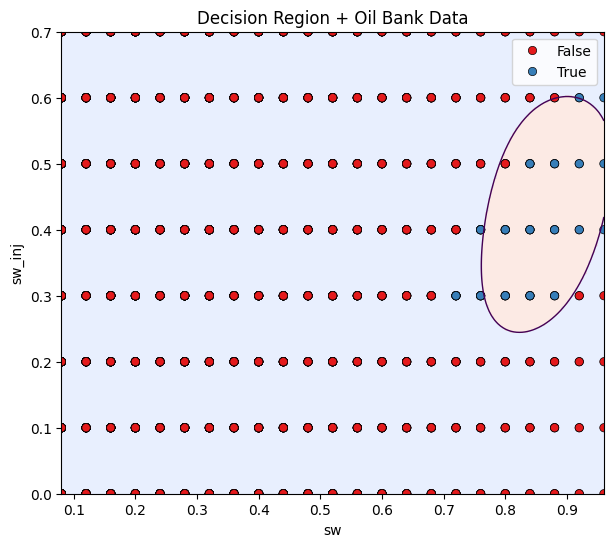

In [64]:
plot_predictions_with_data(best_model, df, feature_idx=(0,2))
plt.show()